Generating AI Technical Support Flowchart...


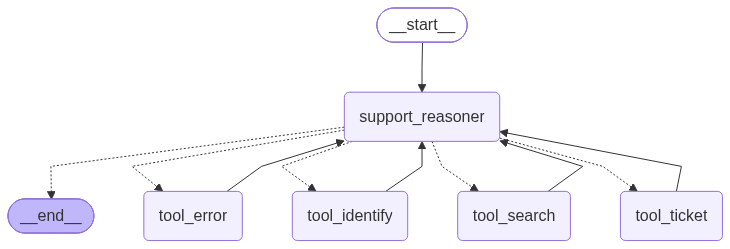


--- Starting Support Desk Execution ---
Node Executed: support_reasoner
Message: Identifying machine...

Node Executed: tool_identify
Message: Identified: MCH-CNC-04

Node Executed: support_reasoner
Message: Checking errors for MCH-CNC-04...

Node Executed: tool_error
Message: ERR-702 (Spindle Overload)

Node Executed: support_reasoner
Message: Searching technical manuals...

Node Executed: tool_search
Message: Manual for ERR-702 (Spindle Overload): 1. Check coolant flow. 2. Verify feed rate. If unresolved, spindle motor requires inspection.

Node Executed: support_reasoner
Message: Attempting fix suggestions. Creating maintenance ticket for record...

Node Executed: tool_ticket
Message: Ticket #TKT-8891 created for MCH-CNC-04. Issue: ERR-702 (Spindle Overload)

Node Executed: support_reasoner
Message: Troubleshooting complete. 
Ticket #TKT-8891 created for MCH-CNC-04. Issue: ERR-702 (Spindle Overload)
Please follow the manual steps provided earlier.



In [1]:
# ---------------------------------------------------------
# 04_AI_Tech_Support_Agent.ipynb
# LangGraph Implementation for AI Technical Support Desk
# ---------------------------------------------------------

import operator
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display

# 1. Define the Graph State
class TechSupportState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    machine_id: str
    error_code: str
    manual_searched: bool
    ticket_created: bool
    next_step: str

# 2. Mocking Tools (MES, Vector Store, and ERP Ticketing)
def identify_machine(operator_input: str) -> str:
    """Extracts machine ID from natural language or user profile context."""
    # Mock extraction
    return "MCH-CNC-04"

def check_error_code(machine_id: str) -> str:
    """Fetches the active alarm/error code for the machine from SCADA/MES."""
    return "ERR-702 (Spindle Overload)"

def search_manual(error_code: str) -> str:
    """Simulates a RAG search over the equipment manuals in the Vector Store."""
    return f"Manual for {error_code}: 1. Check coolant flow. 2. Verify feed rate. If unresolved, spindle motor requires inspection."

def create_ticket(machine_id: str, issue_desc: str) -> str:
    """Creates a maintenance ticket in the ERP system."""
    return f"Ticket #TKT-8891 created for {machine_id}. Issue: {issue_desc}"

# 3. Define the Nodes
def support_reasoner(state: TechSupportState):
    """
    Node 1: Support Agent Reasoner.
    Determines the state of troubleshooting and routes to the appropriate tool.
    """
    # Step A: Identify Machine
    if not state.get('machine_id'):
        operator_msg = state['messages'][0].content
        return {
            "messages": [AIMessage(content="Identifying machine...", tool_calls=[{"name": "identify_machine", "args": {"operator_input": operator_msg}, "id": "call_id1"}])],
            "next_step": "tool_identify"
        }
    
    # Step B: Check Error Code
    elif not state.get('error_code'):
        return {
            "messages": [AIMessage(content=f"Checking errors for {state['machine_id']}...", tool_calls=[{"name": "check_error_code", "args": {"machine_id": state['machine_id']}, "id": "call_err1"}])],
            "next_step": "tool_error"
        }
    
    # Step C: Search Manual using Error Code
    elif not state.get('manual_searched'):
        return {
            "messages": [AIMessage(content="Searching technical manuals...", tool_calls=[{"name": "search_manual", "args": {"error_code": state['error_code']}, "id": "call_man1"}])],
            "next_step": "tool_search"
        }
    
    # Step D: Formulate fix and create ticket
    elif not state.get('ticket_created'):
        return {
            "messages": [AIMessage(content="Attempting fix suggestions. Creating maintenance ticket for record...", tool_calls=[{"name": "create_ticket", "args": {"machine_id": state['machine_id'], "issue_desc": state['error_code']}, "id": "call_tkt1"}])],
            "next_step": "tool_ticket"
        }
    
    # Final state
    else:
        last_tool_msg = state['messages'][-1].content
        final_response = f"Troubleshooting complete. \n{last_tool_msg}\nPlease follow the manual steps provided earlier."
        return {
            "messages": [AIMessage(content=final_response)],
            "next_step": "end"
        }

def tool_identify(state: TechSupportState):
    last_msg = state['messages'][-1]
    tool_call = last_msg.tool_calls[0]
    machine_id = identify_machine(tool_call['args']['operator_input'])
    return {"messages": [ToolMessage(content=f"Identified: {machine_id}", tool_call_id=tool_call['id'])], "machine_id": machine_id, "next_step": "reasoner"}

def tool_error(state: TechSupportState):
    last_msg = state['messages'][-1]
    tool_call = last_msg.tool_calls[0]
    error = check_error_code(tool_call['args']['machine_id'])
    return {"messages": [ToolMessage(content=error, tool_call_id=tool_call['id'])], "error_code": error, "next_step": "reasoner"}

def tool_search(state: TechSupportState):
    last_msg = state['messages'][-1]
    tool_call = last_msg.tool_calls[0]
    manual_info = search_manual(tool_call['args']['error_code'])
    return {"messages": [ToolMessage(content=manual_info, tool_call_id=tool_call['id'])], "manual_searched": True, "next_step": "reasoner"}

def tool_ticket(state: TechSupportState):
    last_msg = state['messages'][-1]
    tool_call = last_msg.tool_calls[0]
    ticket_status = create_ticket(tool_call['args']['machine_id'], tool_call['args']['issue_desc'])
    return {"messages": [ToolMessage(content=ticket_status, tool_call_id=tool_call['id'])], "ticket_created": True, "next_step": "reasoner"}

# 4. Define Routing Logic
def route_next_step(state: TechSupportState):
    step = state.get("next_step")
    if step == "tool_identify": return "tool_identify"
    elif step == "tool_error": return "tool_error"
    elif step == "tool_search": return "tool_search"
    elif step == "tool_ticket": return "tool_ticket"
    elif step == "end": return END
    return "support_reasoner"

# 5. Build the LangGraph
workflow = StateGraph(TechSupportState)

workflow.add_node("support_reasoner", support_reasoner)
workflow.add_node("tool_identify", tool_identify)
workflow.add_node("tool_error", tool_error)
workflow.add_node("tool_search", tool_search)
workflow.add_node("tool_ticket", tool_ticket)

workflow.add_edge(START, "support_reasoner")

workflow.add_conditional_edges(
    "support_reasoner",
    route_next_step,
    {
        "tool_identify": "tool_identify",
        "tool_error": "tool_error",
        "tool_search": "tool_search",
        "tool_ticket": "tool_ticket",
        END: END
    }
)

# Route all tools back to reasoner
for node in ["tool_identify", "tool_error", "tool_search", "tool_ticket"]:
    workflow.add_edge(node, "support_reasoner")

app = workflow.compile()

# 6. Render the Graph Visualization
print("Generating AI Technical Support Flowchart...")
display(Image(app.get_graph().draw_mermaid_png()))

# 7. Execute the Pipeline
print("\n--- Starting Support Desk Execution ---")
initial_state = {
    "messages": [HumanMessage(content="My machine stopped working abruptly during the milling process.")],
    "machine_id": "",
    "error_code": "",
    "manual_searched": False,
    "ticket_created": False,
    "next_step": ""
}

for output in app.stream(initial_state):
    for key, value in output.items():
        print(f"Node Executed: {key}")
        if "messages" in value:
            print(f"Message: {value['messages'][-1].content}\n")